In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (맷플롯립)
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경
matplotlib.rcParams['axes.unicode_minus'] = False

# 전처리 및 분할
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# 모델 정의
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 평가지표 및 시각화 도구
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# 기타 설정
import warnings
warnings.filterwarnings('ignore')


In [2]:
# 데이터 불러오기
file_path = r"D:\python\코드잇 스프린트 데분\codeit-sprint-projects\sprint-missions\스프린트 미션 13\data\processed\bank_cleaned2.csv"
df = pd.read_csv(file_path)

# 특성과 타겟 분리
X = df.drop('y', axis=1)
y = df['y']
# X = X.drop(columns='duration_group')

# 데이터 크기 확인
print(f"전체 데이터 크기: {df.shape}")
print(f"입력 변수 X: {X.shape}")
print(f"타겟 변수 y: {y.shape}")


전체 데이터 크기: (41188, 56)
입력 변수 X: (41188, 55)
타겟 변수 y: (41188,)


In [45]:
print(df.columns.tolist())

['default', 'campaign', 'y', 'was_contacted_before', 'had_previous_contact', 'log_age', 'balance_shift', 'log_emp_var_rate', 'log_cons_price_idx', 'log_cons_conf_idx', 'log_euribor3m', 'log_nr_employed', 'interaction_term', 'contact_ratio', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_rare', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'marital_unknown', 'education_illiterate', 'education_professional.course', 'education_rare', 'education_university.degree', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success', 'age_group_31-40', 'age_group_41-50', 'age_group_51-60', 'age_group_60+']


In [3]:
# 훈련/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# log_cons_conf_idx 열 제거
if 'log_cons_conf_idx' in X.columns:
    X = X.drop(columns='log_cons_conf_idx')



In [5]:
# 사용할 모델 정의 (기본 파라미터)
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(),
    'Naive Bayes': GaussianNB()
}

# 결과 저장용 리스트
results = []

# 각 모델 학습 및 평가
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    results.append({
        '모델': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': auc
    })

# 결과 표로 출력
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
results_df


[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 385
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898


,모델,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Naive Bayes,0.872663,0.434311,0.431034,0.432666,0.770250
1,XGBoost,0.899369,0.610738,0.294181,0.397091,0.798824
2,LightGBM,0.901432,0.650259,0.270474,0.382040,0.810541
3,Random Forest,0.890872,0.527725,0.297414,0.380427,0.772457
4,Gradient Boosting,0.902282,0.686930,0.243534,0.359586,0.810954
5,Logistic Regression,0.897062,0.619760,0.223060,0.328051,0.786950
6,Decision Tree,0.843651,0.317814,0.338362,0.327766,0.623880
7,AdaBoost,0.901675,0.725191,0.204741,0.319328,0.795745


In [17]:
from imblearn.over_sampling import SMOTE

# 결과 저장용 리스트
results = []

# log_cons_conf_idx 열 제거
if 'log_cons_conf_idx' in X_train.columns:
    X_train = X_train.drop(columns='log_cons_conf_idx')
if 'log_cons_conf_idx' in X_test.columns:
    X_test = X_test.drop(columns='log_cons_conf_idx')

# SMOTE 생성
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

# 모델 리스트
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(),
    'Naive Bayes': GaussianNB()
}

# 학습 및 평가 함수
def evaluate_models(X_train, y_train, label):
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

        results.append({
            '모델': name,
            '데이터': label,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            'ROC AUC': auc
        })

# 원본 학습 데이터로 평가
evaluate_models(X_train, y_train, '원본')

# SMOTE 오버샘플링된 데이터로 평가
evaluate_models(X_train_over, y_train_over, 'SMOTE')

# 결과 정리
results_df = pd.DataFrame(results).sort_values(
    by=['모델', '데이터'], ascending=[True, False]
).reset_index(drop=True)

import pandas as pd
import IPython.display as disp
disp.display(results_df)


[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001004 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 471
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898
[LightGBM] [Info] Number of positive: 29238, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005818 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1894
[LightGBM] [Info] Number of data points in the train set: 58476, number of used features: 53
[LightGBM] [Info] [b

,모델,데이터,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,AdaBoost,원본,0.901432,0.726562,0.200431,0.314189,0.796779
1,AdaBoost,SMOTE,0.828963,0.353977,0.628233,0.452816,0.783181
2,Decision Tree,원본,0.840374,0.313404,0.350216,0.330789,0.628589
3,Decision Tree,SMOTE,0.836732,0.321642,0.405172,0.358608,0.650236
4,Gradient Boosting,원본,0.901797,0.685358,0.237069,0.352282,0.809268
5,Gradient Boosting,SMOTE,0.871085,0.446141,0.598060,0.511050,0.799728
6,LightGBM,원본,0.902403,0.658163,0.278017,0.390909,0.810213
7,LightGBM,SMOTE,0.889415,0.509605,0.485991,0.497518,0.797201
8,Logistic Regression,원본,0.901190,0.714286,0.204741,0.318258,0.798006
9,Logistic Regression,SMOTE,0.798980,0.290081,0.542026,0.377911,0.741316


In [6]:
from imblearn.over_sampling import SMOTE

# 결과 저장용 리스트
results = []

# 훈련/테스트 분할

# SMOTE 생성
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

# 모델 리스트
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(),
    'Naive Bayes': GaussianNB()
}

# 학습 및 평가 함수
def evaluate_models(X_train, y_train, label):
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

        results.append({
            '모델': name,
            '데이터': label,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            'ROC AUC': auc
        })

# 원본 학습 데이터로 평가
evaluate_models(X_train, y_train, '원본')

# SMOTE 오버샘플링된 데이터로 평가
evaluate_models(X_train_over, y_train_over, 'SMOTE')

# 결과 정리
results_df = pd.DataFrame(results).sort_values(
    by=['모델', '데이터'], ascending=[True, False]
).reset_index(drop=True)

import pandas as pd
import IPython.display as disp
disp.display(results_df)


[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000872 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 385
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898
[LightGBM] [Info] Number of positive: 29238, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 902
[LightGBM] [Info] Number of data points in the train set: 58476, number of used features: 53
[LightGBM] [Info] [bi

,모델,데이터,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,AdaBoost,원본,0.901675,0.725191,0.204741,0.319328,0.795745
1,AdaBoost,SMOTE,0.836732,0.367451,0.622845,0.462215,0.781113
2,Decision Tree,원본,0.843651,0.316701,0.335129,0.325654,0.622518
3,Decision Tree,SMOTE,0.833333,0.304996,0.375000,0.336394,0.639296
4,Gradient Boosting,원본,0.902282,0.686930,0.243534,0.359586,0.810913
5,Gradient Boosting,SMOTE,0.863802,0.428148,0.622845,0.507463,0.792351
6,LightGBM,원본,0.901432,0.650259,0.270474,0.382040,0.810541
7,LightGBM,SMOTE,0.876790,0.460633,0.548491,0.500738,0.793919
8,Logistic Regression,원본,0.897062,0.619760,0.223060,0.328051,0.786950
9,Logistic Regression,SMOTE,0.784292,0.289330,0.628233,0.396194,0.766317


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# log_cons_conf_idx 열 제거
if 'log_cons_conf_idx' in X.columns:
    X = X.drop(columns='log_cons_conf_idx')


# 🧪 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)



# 📏 StandardScaler 적용 (수치형만 스케일링)
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 🔁 로지스틱 회귀 모델 학습
logreg = LogisticRegression(max_iter=1000, solver='lbfgs')
logreg.fit(X_train, y_train)

# 🔍 예측 및 평가
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

# 📊 평가 지표 출력
print("✅ Logistic Regression + StandardScaler 결과")
print(classification_report(y_test, y_pred, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


✅ Logistic Regression + StandardScaler 결과
              precision    recall  f1-score   support

           0     0.9083    0.9890    0.9469     10965
           1     0.7105    0.2134    0.3282      1392

    accuracy                         0.9016     12357
   macro avg     0.8094    0.6012    0.6375     12357
weighted avg     0.8860    0.9016    0.8772     12357

ROC AUC: 0.8042173766058146


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE


# log_cons_conf_idx 열 제거
if 'log_cons_conf_idx' in X.columns:
    X = X.drop(columns='log_cons_conf_idx')

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# SMOTE 적용
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# StandardScaler 적용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression 모델 학습
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_res)

# 예측 및 평가
y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

# 평가지표 계산
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_proba)

# 결과 정리
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [
        report['accuracy'],
        report['1']['precision'],
        report['1']['recall'],
        report['1']['f1-score'],
        roc_auc
    ]
})

results_df

,Metric,Value
0,Accuracy,0.807963
1,Precision,0.305125
2,Recall,0.551724
3,F1 Score,0.392939
4,ROC AUC,0.748273


In [30]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# 오버샘플링은 학습용 데이터에만 적용
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 이후 LightGBM 모델 학습
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_res, y_train_res)


# 예측
y_pred = lgbm.predict(X_test)
y_proba = lgbm.predict_proba(X_test)[:, 1]

# 평가 지표 계산
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_proba)

# 필요한 값 추출 후 DataFrame으로 변환
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [
        report['accuracy'],
        report['1']['precision'],
        report['1']['recall'],
        report['1']['f1-score'],
        roc_auc
    ]
})

# 결과 출력
results_df


[LightGBM] [Info] Number of positive: 29238, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004604 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 902
[LightGBM] [Info] Number of data points in the train set: 58476, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Metric,Value
0,Accuracy,0.876790
1,Precision,0.460633
2,Recall,0.548491
3,F1 Score,0.500738
4,ROC AUC,0.793919


In [52]:
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline  # ✅ imblearn의 Pipeline 사용
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 파이프라인 구성
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])

# 하이퍼파라미터 탐색 범위
param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__num_leaves': [31, 63],
    'model__max_depth': [-1, 10],
    'model__min_child_samples': [20, 30],
    'model__subsample': [0.8, 0.9],
    'model__colsample_bytree': [0.8, 0.9]
}

# RandomizedSearchCV 실행
search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# 학습
search.fit(X_train, y_train)

# 최적 모델로 예측
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# 평가 결과 표로 출력
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_proba)
}

results_df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"])
results_df


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 25583, number of negative: 25583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004833 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9670
[LightGBM] [Info] Number of data points in the train set: 51166, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Metric,Value
0,Accuracy,0.882981
1,Precision,0.482933
2,Recall,0.548851
3,F1 Score,0.513786
4,ROC AUC,0.808254


In [55]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

# 기존 best_model로 확률 예측
y_proba_thresh = best_model.predict_proba(X_test)[:, 1]

# 원하는 threshold 설정 (예: 0.3)
threshold = 0.45
y_pred_thresh = (y_proba_thresh >= threshold).astype(int)

# 평가 지표 계산
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_thresh, average='binary'
)
roc_auc = roc_auc_score(y_test, y_proba_thresh)
accuracy = (y_pred_thresh == y_test).mean()

# 결과 표로 정리
threshold_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [accuracy, precision, recall, f1, roc_auc]
})

threshold_results


,Metric,Value
0,Accuracy,0.875212
1,Precision,0.458380
2,Recall,0.593391
3,F1 Score,0.517220
4,ROC AUC,0.808254


1. duration 넣고 돌려보기 / 비교
2. Recall에 중점
3. F1 Score까지 종합적으로 살펴보기
4. 

5. 아무런 것도 x
6. 언더샘플링 < 시도해보자! >
7. 오버샘플링

In [ ]:
	Metric	Value
0	Accuracy	0.887837
1	Precision	0.502229
2	Recall	0.485632
3	F1 Score	0.493791
4	ROC AUC	0.803715



	Metric	Value
0	Accuracy	0.882981
1	Precision	0.482933
2	Recall	0.548851
3	F1 Score	0.513786
4	ROC AUC	0.808254




In [4]:
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# 예시용 데이터 로딩 (실제 실행에서는 사용자 데이터 필요)
# from sklearn.datasets import make_classification
# X, y = make_classification(n_samples=1000, n_features=20, weights=[0.9, 0.1], random_state=42)

# 데이터를 로드했다고 가정
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 공통 파라미터
param_grid = {
    'model__n_estimators': [100],
    'model__learning_rate': [0.1],
    'model__num_leaves': [31],
    'model__max_depth': [-1],
    'model__min_child_samples': [20],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8]
}

# 평가 저장용
results = []

# 방법 1: 오버샘플링 (SMOTE)
pipeline_over = Pipeline([
    ('scaler', StandardScaler()),
    ('sampler', SMOTE(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])
pipeline_over.fit(X_train, y_train)
y_pred_over = pipeline_over.predict(X_test)
y_proba_over = pipeline_over.predict_proba(X_test)[:, 1]
results.append({
    "Method": "SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_over),
    "Precision": precision_score(y_test, y_pred_over),
    "Recall": recall_score(y_test, y_pred_over),
    "F1 Score": f1_score(y_test, y_pred_over),
    "ROC AUC": roc_auc_score(y_test, y_proba_over)
})

# 방법 2: 언더샘플링
pipeline_under = Pipeline([
    ('scaler', StandardScaler()),
    ('sampler', RandomUnderSampler(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])
pipeline_under.fit(X_train, y_train)
y_pred_under = pipeline_under.predict(X_test)
y_proba_under = pipeline_under.predict_proba(X_test)[:, 1]
results.append({
    "Method": "UnderSampling",
    "Accuracy": accuracy_score(y_test, y_pred_under),
    "Precision": precision_score(y_test, y_pred_under),
    "Recall": recall_score(y_test, y_pred_under),
    "F1 Score": f1_score(y_test, y_pred_under),
    "ROC AUC": roc_auc_score(y_test, y_proba_under)
})

# 방법 3: 샘플링 없이
pipeline_none = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LGBMClassifier(random_state=42))
])
pipeline_none.fit(X_train, y_train)
y_pred_none = pipeline_none.predict(X_test)
y_proba_none = pipeline_none.predict_proba(X_test)[:, 1]
results.append({
    "Method": "No Sampling",
    "Accuracy": accuracy_score(y_test, y_pred_none),
    "Precision": precision_score(y_test, y_pred_none),
    "Recall": recall_score(y_test, y_pred_none),
    "F1 Score": f1_score(y_test, y_pred_none),
    "ROC AUC": roc_auc_score(y_test, y_proba_none)
})

# 결과 정리
comparison_df = pd.DataFrame(results)
comparison_df

[LightGBM] [Info] Number of positive: 25583, number of negative: 25583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004754 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9670
[LightGBM] [Info] Number of data points in the train set: 51166, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 3248, number of negative: 3248
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000523 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 467
[LightGBM] [Info] Number of data points in the train set: 6496, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.00000

,Method,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,SMOTE,0.900704,0.620438,0.305316,0.409244,0.806492
1,UnderSampling,0.822125,0.350741,0.680316,0.462854,0.805091
2,No Sampling,0.901918,0.666052,0.259339,0.373320,0.809861


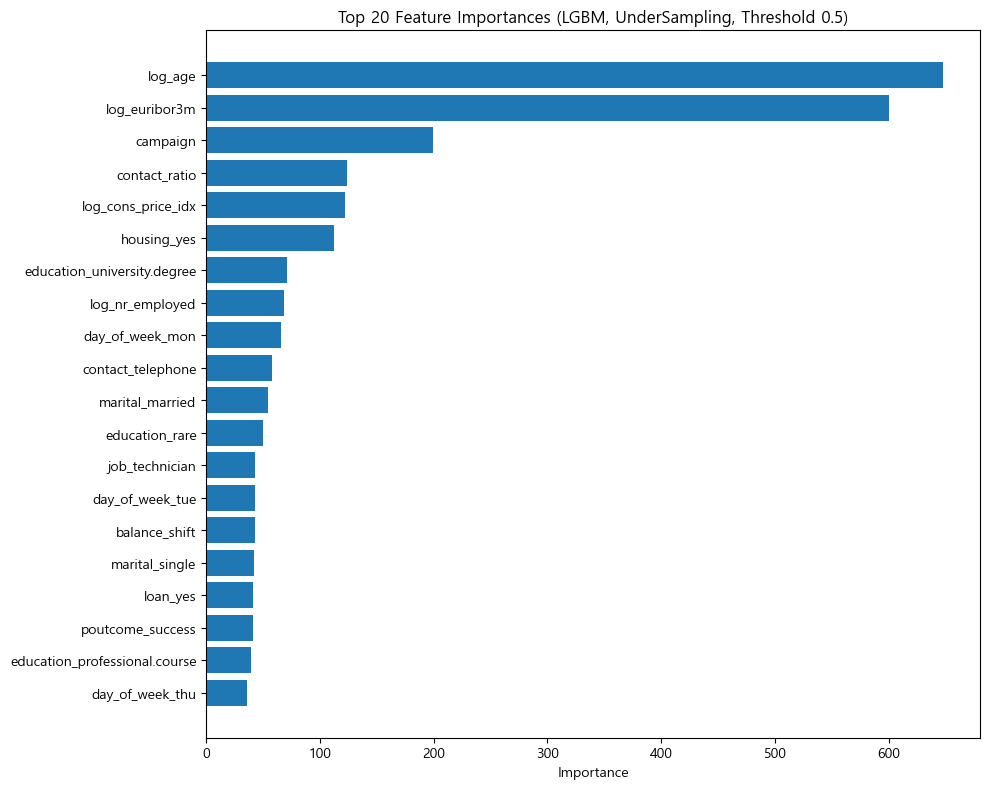

,Feature,Importance
4,log_age,648
8,log_euribor3m,600
1,campaign,199
11,contact_ratio,124
7,log_cons_price_idx,122
31,housing_yes,112
29,education_university.degree,71
9,log_nr_employed,68
44,day_of_week_mon,66
34,contact_telephone,58


In [6]:
from lightgbm import LGBMClassifier
import pandas as pd
import matplotlib.pyplot as plt

# 언더샘플링에서 사용했던 최종 모델 구성 (기존 성능 기준)
# 모델은 이미 훈련된 상태라고 가정하고 새로 훈련하지 않음

# 예시: 특성 중요도 추출 및 정렬
feature_importances = pipeline_under.named_steps['model'].feature_importances_
feature_names = X.columns  # 기존 전처리된 X 사용

# 데이터프레임으로 정리
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 상위 20개만 시각화
top_n = 20
top_features = importance_df.head(top_n)

# 시각화
plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Feature Importances (LGBM, UnderSampling, Threshold 0.5)")
plt.tight_layout()
plt.show()

# 표로도 출력
top_features

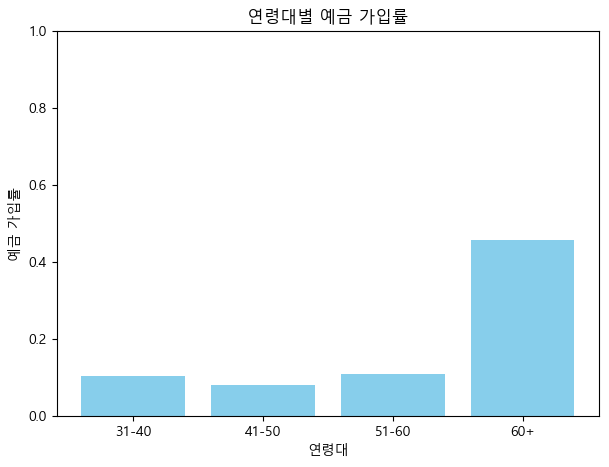

In [9]:
import matplotlib.pyplot as plt

# 1. 연령대별 예금 가입률 비교 그래프
age_groups = ['age_group_31-40', 'age_group_41-50', 'age_group_51-60', 'age_group_60+']
age_labels = ['31-40', '41-50', '51-60', '60+']

# 각 연령대별 가입률 계산
age_rates = []
for col in age_groups:
    mask = X_test[col]
    if mask.sum() > 0:
        rate = y_test[mask].mean()
    else:
        rate = 0
    age_rates.append(rate)

plt.figure(figsize=(7, 5))
plt.bar(age_labels, age_rates, color='skyblue')
plt.ylabel('예금 가입률')
plt.xlabel('연령대')
plt.title('연령대별 예금 가입률')
plt.ylim(0, 1)
plt.show()

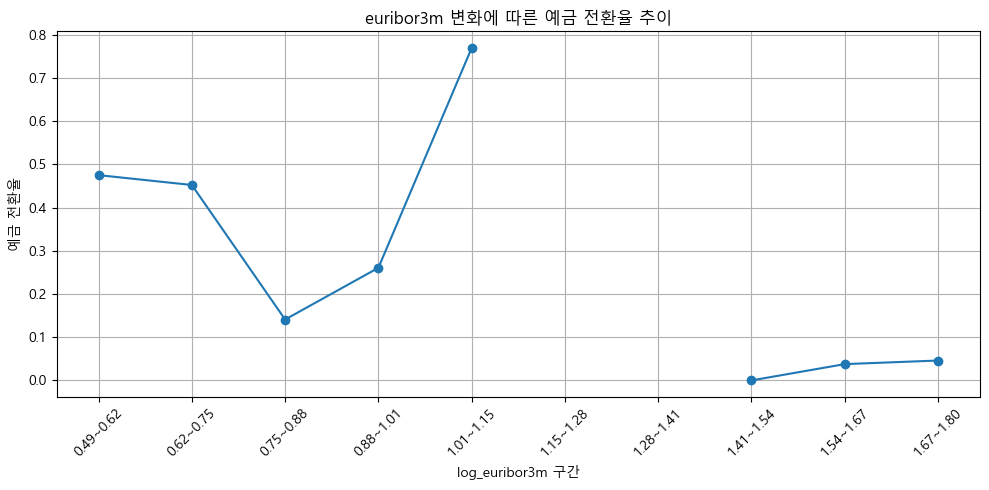

In [10]:
import numpy as np

import matplotlib.pyplot as plt

# 구간 나누기 (예: 10개 구간)
euribor_col = 'log_euribor3m'
n_bins = 10
euribor_values = X_test[euribor_col]
bins = np.linspace(euribor_values.min(), euribor_values.max(), n_bins + 1)
labels = [f"{bins[i]:.2f}~{bins[i+1]:.2f}" for i in range(n_bins)]
euribor_bin = pd.cut(euribor_values, bins=bins, labels=labels, include_lowest=True)

# 각 구간별 예금 전환율 계산
conversion_rates = y_test.groupby(euribor_bin).mean()

plt.figure(figsize=(10, 5))
plt.plot(labels, conversion_rates, marker='o')
plt.xlabel('log_euribor3m 구간')
plt.ylabel('예금 전환율')
plt.title('euribor3m 변화에 따른 예금 전환율 추이')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

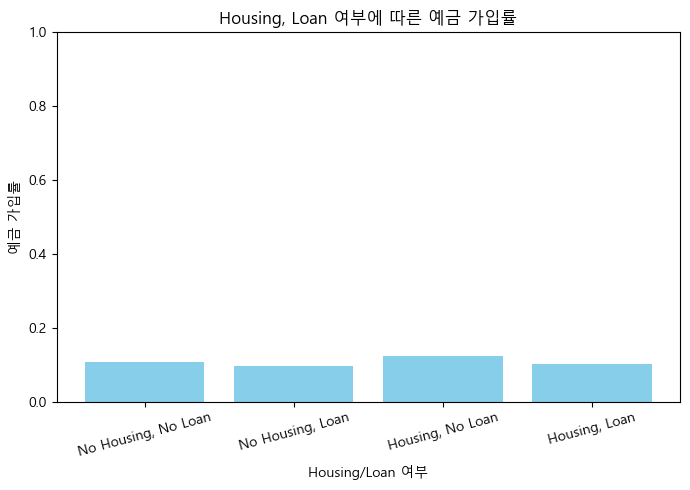

In [11]:
import matplotlib.pyplot as plt

# housing, loan 조합별 가입률 계산
group_cols = ['housing_yes', 'loan_yes']
group_labels = {
    (False, False): 'No Housing, No Loan',
    (False, True): 'No Housing, Loan',
    (True, False): 'Housing, No Loan',
    (True, True): 'Housing, Loan'
}

# X_test와 y_test를 합쳐서 분석
df_test = X_test.copy()
df_test['y'] = y_test.values

# 조합별 가입률
rates = []
labels = []
for h in [False, True]:
    for l in [False, True]:
        mask = (df_test['housing_yes'] == h) & (df_test['loan_yes'] == l)
        rate = df_test.loc[mask, 'y'].mean() if mask.sum() > 0 else 0
        rates.append(rate)
        labels.append(group_labels[(h, l)])

plt.figure(figsize=(7, 5))
plt.bar(labels, rates, color='skyblue')
plt.ylabel('예금 가입률')
plt.xlabel('Housing/Loan 여부')
plt.title('Housing, Loan 여부에 따른 예금 가입률')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# --

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# 데이터 불러오기
file_path = r"D:\python\코드잇 스프린트 데분\codeit-sprint-projects\sprint-missions\스프린트 미션 13\data\processed\bank_cleaned3.csv"
df_cleaned3 = pd.read_csv(file_path)


# 타겟 분리
X = df_cleaned3.drop(columns='y')
y = df_cleaned3['y']

# log_cons_conf_idx 열 제거
if 'log_cons_conf_idx' in X.columns:
    X = X.drop(columns='log_cons_conf_idx')

# 결과 저장용
results = []

# 공통 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)



# 1. SMOTE
pipe_smote = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])
pipe_smote.fit(X_train, y_train)
pred = pipe_smote.predict(X_test)
proba = pipe_smote.predict_proba(X_test)[:, 1]
results.append({
    "Method": "SMOTE",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1 Score": f1_score(y_test, pred),
    "ROC AUC": roc_auc_score(y_test, proba)
})

# 2. UnderSampling
pipe_under = Pipeline([
    ('scaler', StandardScaler()),
    ('under', RandomUnderSampler(random_state=42)),
    ('model', LGBMClassifier(random_state=42))
])
pipe_under.fit(X_train, y_train)
pred = pipe_under.predict(X_test)
proba = pipe_under.predict_proba(X_test)[:, 1]
results.append({
    "Method": "UnderSampling",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1 Score": f1_score(y_test, pred),
    "ROC AUC": roc_auc_score(y_test, proba)
})

# 3. No Sampling
pipe_none = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LGBMClassifier(random_state=42))
])
pipe_none.fit(X_train, y_train)
pred = pipe_none.predict(X_test)
proba = pipe_none.predict_proba(X_test)[:, 1]
results.append({
    "Method": "No Sampling",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1 Score": f1_score(y_test, pred),
    "ROC AUC": roc_auc_score(y_test, proba)
})

# 결과 표 출력
results_df = pd.DataFrame(results)
results_df


[LightGBM] [Info] Number of positive: 25583, number of negative: 25583
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9941
[LightGBM] [Info] Number of data points in the train set: 51166, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 3248, number of negative: 3248
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 722
[LightGBM] [Info] Number of data points in the train set: 6496, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.00000

,Method,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,SMOTE,0.917132,0.623989,0.665230,0.643950,0.949356
1,UnderSampling,0.861050,0.444444,0.933908,0.602270,0.945538
2,No Sampling,0.919398,0.671577,0.556753,0.608798,0.950615


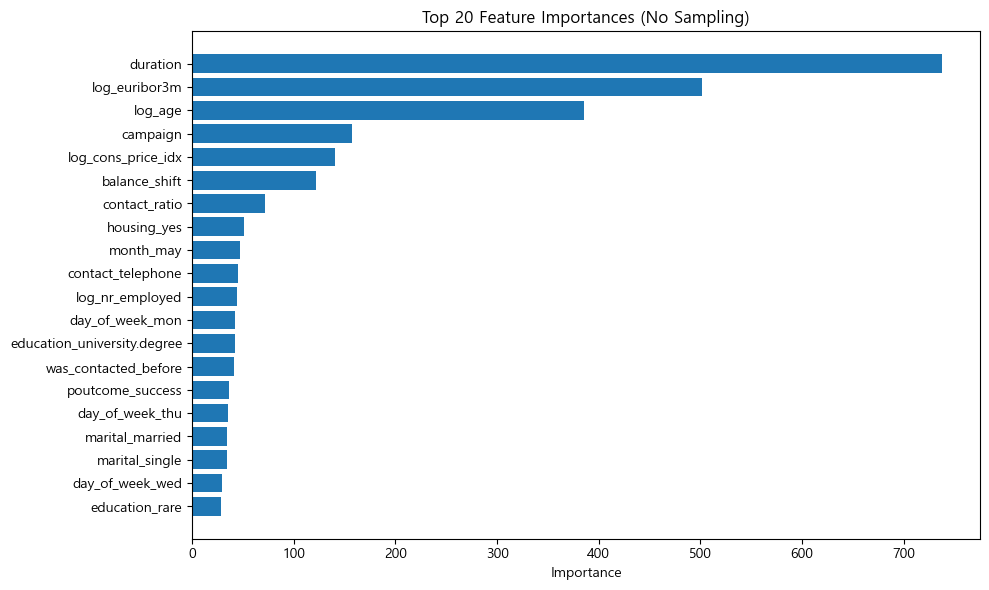

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# 최종 모델: 샘플링 없음
final_model = pipe_none.named_steps['model']
final_features = X.columns

# 중요도 정렬
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]

# 상위 20개만 시각화
plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances (No Sampling)")
plt.barh(range(20), importances[indices[:20]][::-1])
plt.yticks(range(20), [final_features[i] for i in indices[:20]][::-1])
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
